## Импорты

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import fft, fftfreq, ifft
import scipy.signal as sig
import scipy
%matplotlib inline

## Пункт 1

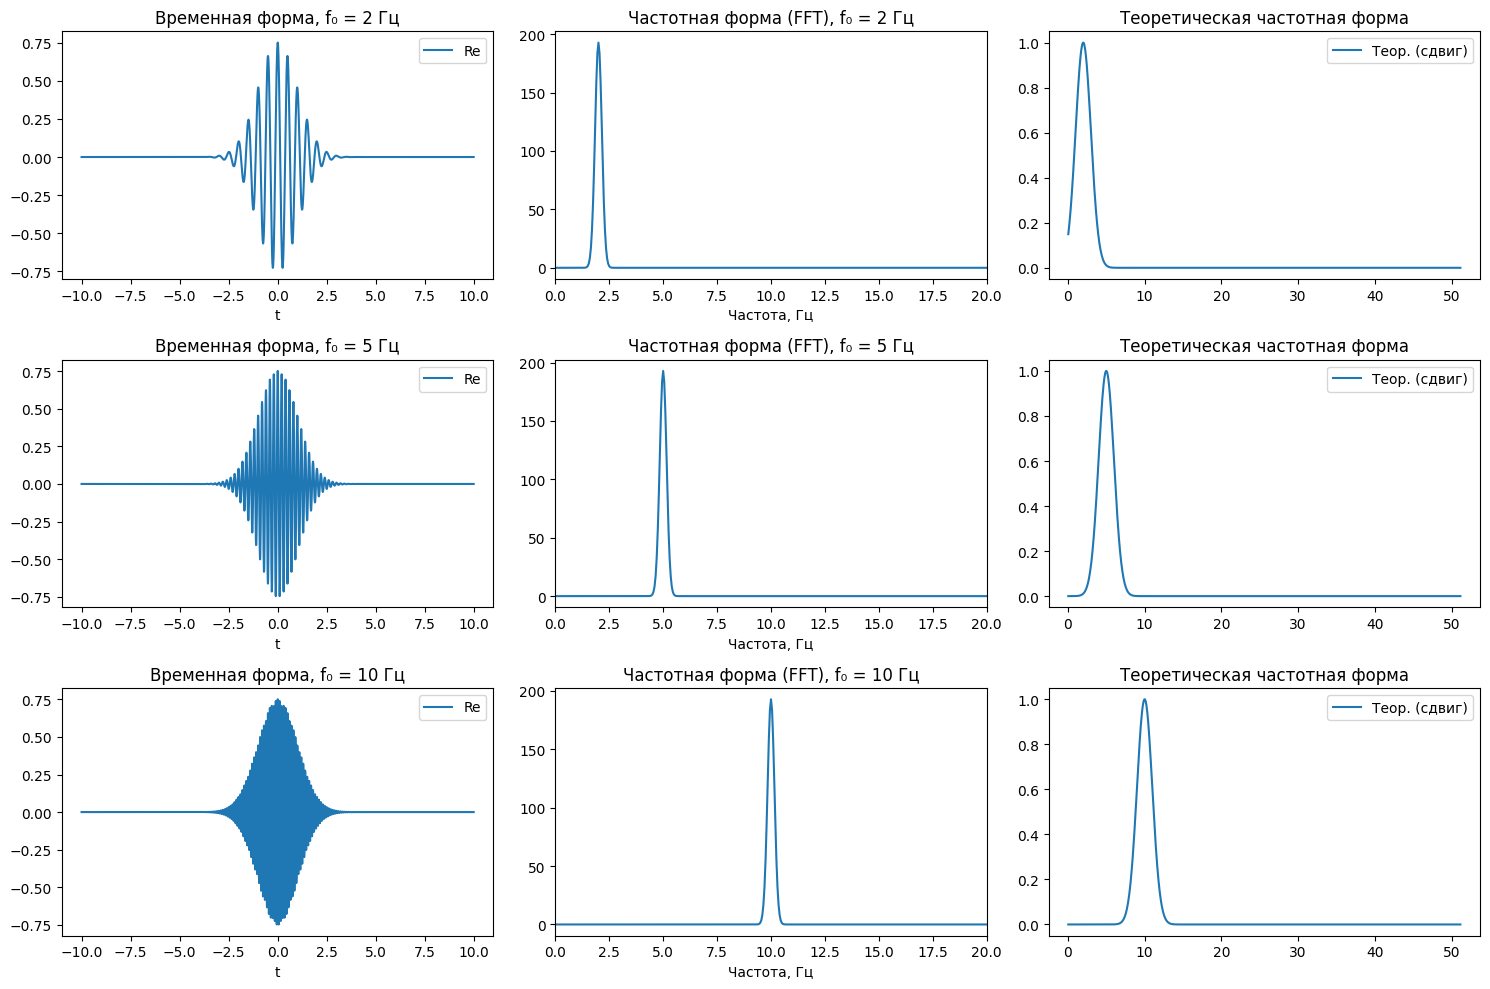

In [3]:
# Параметры
t = np.linspace(-10, 10, 2048, endpoint=False)
dt = t[1] - t[0]

def morlet_time(t, f0=5.0, sigma=1.0):
    """Вейвлет Морле во временной области (формула 1)"""
    norm = np.pi**(-0.25) / np.sqrt(sigma)
    gaussian = np.exp(-t**2 / (2 * sigma**2))
    complex_exp = np.exp(1j * 2 * np.pi * f0 * t)
    return norm * gaussian * complex_exp

# Построим временную и частотную форму при разных f0
f0_values = [2, 5, 10]

fig, axs = plt.subplots(len(f0_values), 3, figsize=(15, 10))
for i, f0 in enumerate(f0_values):
    psi = morlet_time(t, f0=f0, sigma=1.0)
    
    # Временная форма (real + imag + abs)
    axs[i, 0].plot(t, np.real(psi), label='Re')
    # axs[i, 0].plot(t, np.imag(psi), label='Im')
    # axs[i, 0].plot(t, np.abs(psi), '--', label='|ψ|')
    axs[i, 0].set_title(f'Временная форма, f₀ = {f0} Гц')
    axs[i, 0].set_xlabel('t')
    axs[i, 0].legend()
    
    # Частотная форма (FFT)
    psi_fft = fft(psi)
    freq = fftfreq(len(t), dt)
    idx = freq > 0
    axs[i, 1].plot(freq[idx], np.abs(psi_fft[idx]))
    axs[i, 1].set_title(f'Частотная форма (FFT), f₀ = {f0} Гц')
    axs[i, 1].set_xlabel('Частота, Гц')
    axs[i, 1].set_xlim(0, 20)
    
    # Теоретическая частотная форма (приближённо Гаусс вокруг f0)
    gauss_freq = np.exp(-(freq - f0)**2 / 2)
    axs[i, 2].plot(freq[idx], gauss_freq[idx], label='Теор. (сдвиг)')
    axs[i, 2].set_title('Теоретическая частотная форма')
    axs[i, 2].legend()

plt.tight_layout()
plt.show()

## Пункт 2

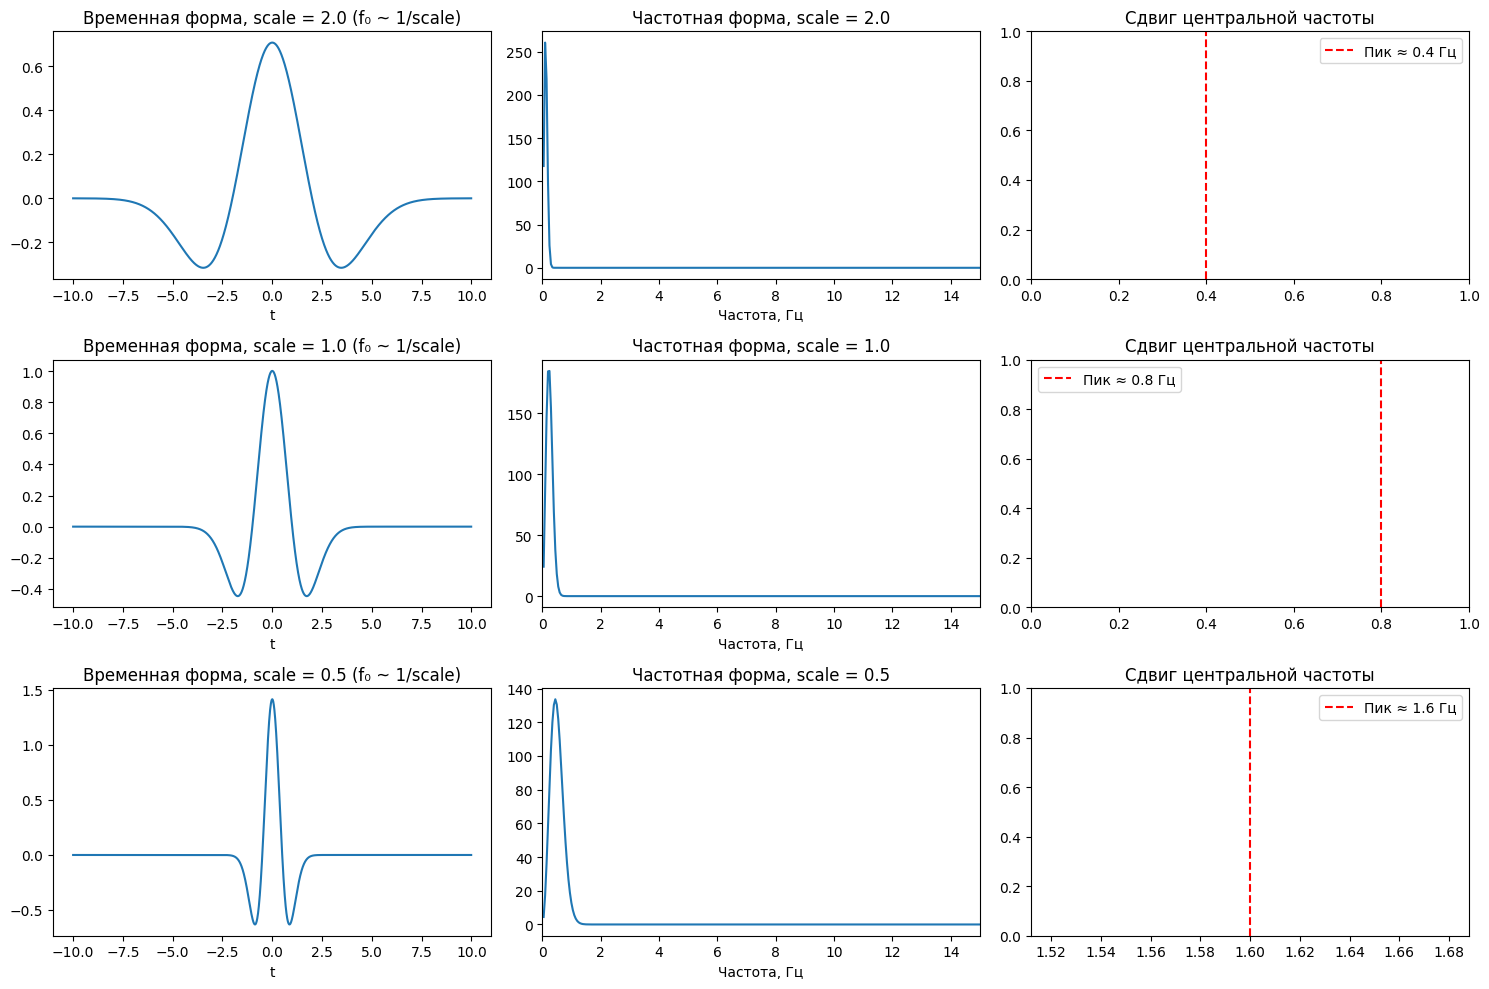

In [4]:
def mexican_hat_time(t, scale=1.0):
    """Мексиканская шляпа во временной области (формула 3)"""
    # Нормализованная формула
    t_scaled = t / scale
    psi = (2 / (np.sqrt(3 * np.pi**0.25))) * (1 - t_scaled**2) * np.exp(-t_scaled**2 / 2)
    return psi / np.sqrt(scale)  # масштабирование для энергии

# Смещение основной частоты — через параметр scale (scale ~ 1/f0)
scales = [2.0, 1.0, 0.5]   # большие scale → низкие частоты

fig, axs = plt.subplots(len(scales), 3, figsize=(15, 10))
for i, sc in enumerate(scales):
    psi = mexican_hat_time(t, scale=sc)
    
    axs[i, 0].plot(t, psi)
    axs[i, 0].set_title(f'Временная форма, scale = {sc:.1f} (f₀ ~ 1/scale)')
    axs[i, 0].set_xlabel('t')
    
    # Частотная форма
    psi_fft = fft(psi)
    freq = fftfreq(len(t), dt)
    idx = freq > 0
    axs[i, 1].plot(freq[idx], np.abs(psi_fft[idx]))
    axs[i, 1].set_title(f'Частотная форма, scale = {sc:.1f}')
    axs[i, 1].set_xlabel('Частота, Гц')
    axs[i, 1].set_xlim(0, 15)
    
    # Теоретический пик частоты для Mexican Hat ≈ 0.8 / scale (примерно)
    f_peak = 0.8 / sc
    axs[i, 2].axvline(f_peak, color='r', linestyle='--', label=f'Пик ≈ {f_peak:.1f} Гц')
    axs[i, 2].set_title('Сдвиг центральной частоты')
    axs[i, 2].legend()

plt.tight_layout()
plt.show()

## Пункт 3

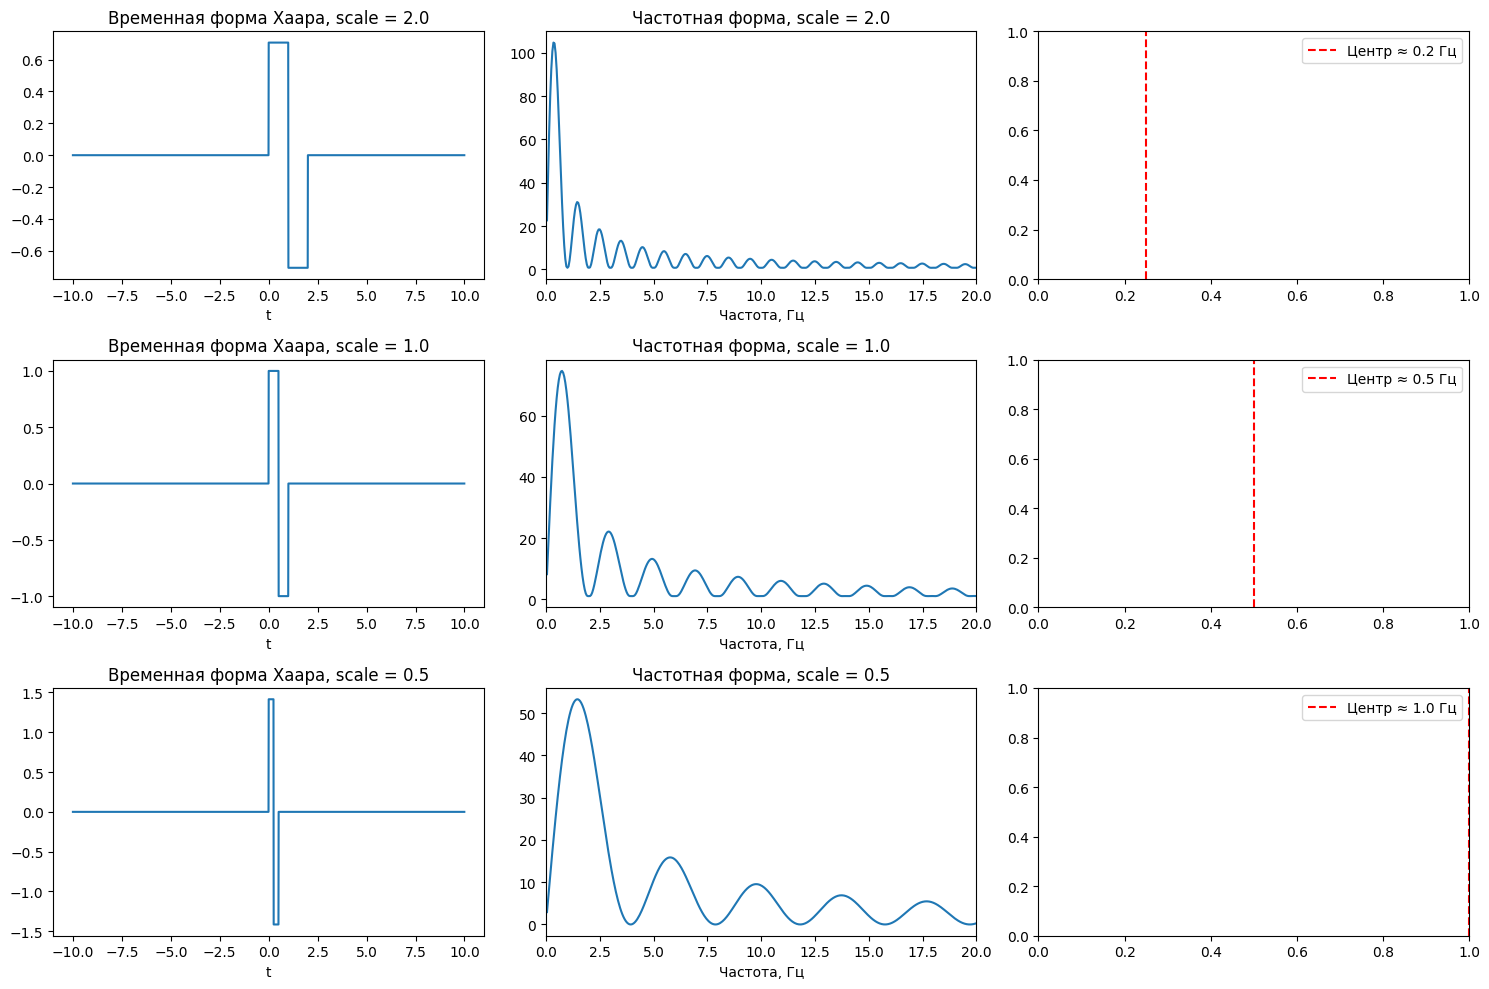

In [5]:
def haar_time(t, scale=1.0):
    """Вейвлет Хаара (формула 5)"""
    psi = np.zeros_like(t)
    mask1 = (t >= 0) & (t < 0.5 * scale)
    mask2 = (t >= 0.5 * scale) & (t < 1.0 * scale)
    psi[mask1] = 1.0
    psi[mask2] = -1.0
    return psi / np.sqrt(scale)  # нормировка

# Масштабирование (формула 7)
scales_haar = [2.0, 1.0, 0.5]

fig, axs = plt.subplots(len(scales_haar), 3, figsize=(15, 10))
for i, sc in enumerate(scales_haar):
    psi = haar_time(t, scale=sc)
    
    axs[i, 0].plot(t, psi)
    axs[i, 0].set_title(f'Временная форма Хаара, scale = {sc:.1f}')
    axs[i, 0].set_xlabel('t')
    
    psi_fft = fft(psi)
    freq = fftfreq(len(t), dt)
    idx = freq > 0
    axs[i, 1].plot(freq[idx], np.abs(psi_fft[idx]))
    axs[i, 1].set_title(f'Частотная форма, scale = {sc:.1f}')
    axs[i, 1].set_xlabel('Частота, Гц')
    axs[i, 1].set_xlim(0, 20)
    
    # Центральная частота ~ 0.5 / scale
    f_c = 0.5 / sc
    axs[i, 2].axvline(f_c, color='r', linestyle='--', label=f'Центр ≈ {f_c:.1f} Гц')
    axs[i, 2].legend()

plt.tight_layout()
plt.show()

## Пункт 4

C:\Users\Kamen\AppData\Local\Temp\ipykernel_2064\2623564945.py:54: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


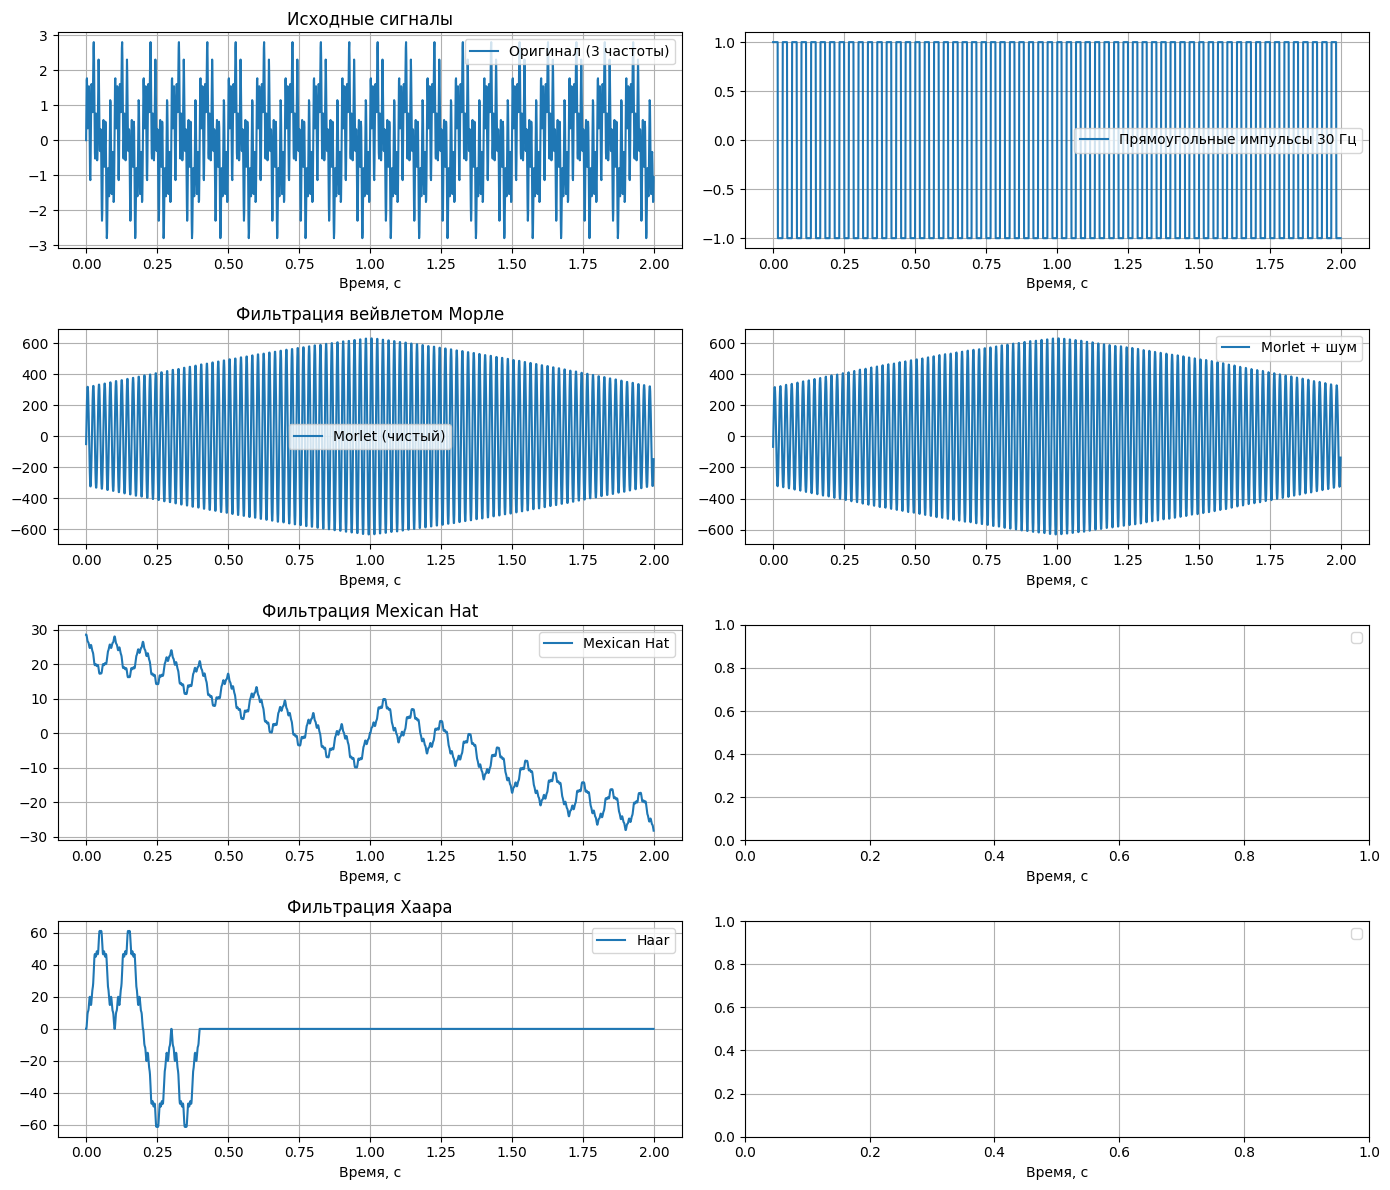

In [7]:
## 4. Свёртка сигналов с вейвлетами (фильтрация)

# Два тестовых сигнала
fs = 1000
t_sig = np.arange(0, 2, 1/fs)
signal_a = (np.sin(2*np.pi*10*t_sig) + 
            np.sin(2*np.pi*50*t_sig) + 
            np.sin(2*np.pi*120*t_sig))   # три частоты

signal_b = sig.square(2*np.pi*30*t_sig)   # прямоугольные импульсы 30 Гц

# Добавим шум
noise = 0.5 * np.random.randn(len(t_sig))
signal_a_noisy = signal_a + noise
signal_b_noisy = signal_b + noise

# ====================== ИСПРАВЛЕННАЯ ФУНКЦИЯ ======================
def wavelet_convolve(signal_data, wavelet_func, param):
    """Свертка сигнала с вейвлетом (исправлено!)"""
    # Центрируем временную сетку под длину сигнала
    t_wave = t_sig - t_sig.mean()
    wav = wavelet_func(t_wave, param)
    # Берём вещественную часть (для Морле) и делаем свертку
    return sig.convolve(signal_data, np.real(wav), mode='same')

# ====================== Фильтрация ======================
# Morlet — фильтруем на частоте 50 Гц
conv_mor_a       = wavelet_convolve(signal_a, 
                                    lambda t, p: np.real(morlet_time(t, f0=p)), 
                                    50)
conv_mor_a_noisy = wavelet_convolve(signal_a_noisy, 
                                    lambda t, p: np.real(morlet_time(t, f0=p)), 
                                    50)

# Mexican Hat
conv_mex_a = wavelet_convolve(signal_a, mexican_hat_time, scale_mex)

# Haar
conv_haar_a = wavelet_convolve(signal_a, haar_time, scale_haar)

# ====================== Визуализация ======================
fig, axs = plt.subplots(4, 2, figsize=(14, 12))

axs[0,0].plot(t_sig, signal_a, label='Оригинал (3 частоты)')
axs[0,1].plot(t_sig, signal_b, label='Прямоугольные импульсы 30 Гц')

axs[1,0].plot(t_sig, conv_mor_a, label='Morlet (чистый)')
axs[1,1].plot(t_sig, conv_mor_a_noisy, label='Morlet + шум')

axs[2,0].plot(t_sig, conv_mex_a, label='Mexican Hat')
axs[3,0].plot(t_sig, conv_haar_a, label='Haar')

for ax in axs.flat:
    ax.legend()
    ax.grid(True)
    ax.set_xlabel('Время, с')

axs[0,0].set_title('Исходные сигналы')
axs[1,0].set_title('Фильтрация вейвлетом Морле')
axs[2,0].set_title('Фильтрация Mexican Hat')
axs[3,0].set_title('Фильтрация Хаара')

plt.tight_layout()
plt.show()

## Пункт 5

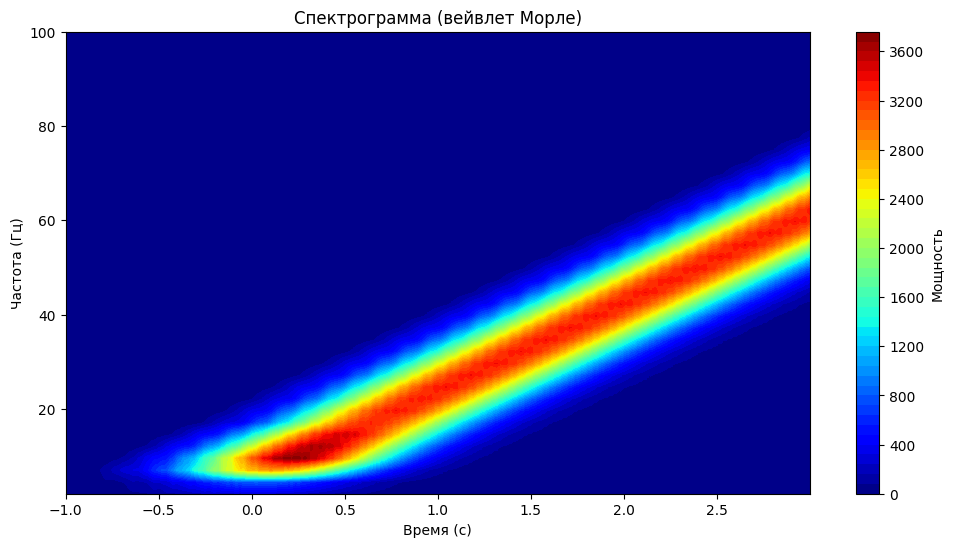

In [10]:
# Параметры (как в описании лабораторной)
srate = 500
time = np.arange(-1, 3, 1/srate)
n = len(time)

# Частотная модуляция (пример: линейный чирп)
freqmod = np.linspace(5, 80, n)          # от 5 до 80 Гц
signal = np.sin(2 * np.pi * (np.cumsum(freqmod) / srate))

# Частоты анализа
frex = np.linspace(2, 100, 40)

# Формируем вейвлеты Морле
wavelets = np.zeros((len(frex), n), dtype=complex)
sigma = 0.5  # ширина гауссова окна
gaussian = np.exp(-time**2 / (2 * sigma**2))

for wi in range(len(frex)):
    wavelets[wi, :] = np.exp(1j * 2 * np.pi * frex[wi] * time) * gaussian

# Свёртка через FFT (как в алгоритме лабораторной)
nconv = n * 2 - 1
sigX = scipy.fftpack.fft(signal, nconv)
tf = np.zeros((len(frex), n))

for fi in range(len(frex)):
    waveX = scipy.fftpack.fft(wavelets[fi, :], nconv)
    convres = scipy.fftpack.ifft(waveX * sigX)
    tf[fi, :] = np.abs(convres[:n])**2   # мощность

# Визуализация спектрограммы
plt.figure(figsize=(12, 6))
plt.contourf(time, frex, tf, levels=50, cmap='jet')
plt.colorbar(label='Мощность')
plt.xlabel('Время (с)')
plt.ylabel('Частота (Гц)')
plt.title('Спектрограмма (вейвлет Морле)')
plt.show()

## Пункт 6

Спектрограмма чистой ноты 440 Гц (должна быть горизонтальная линия на 440 Гц)


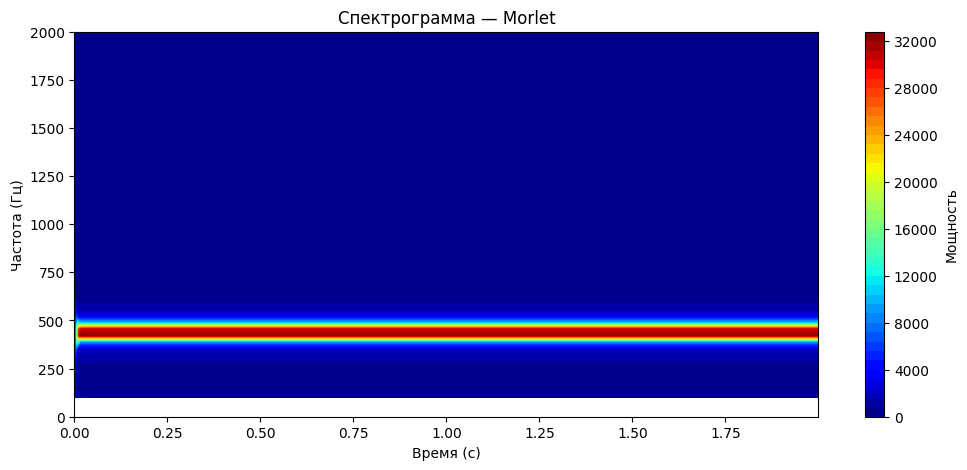

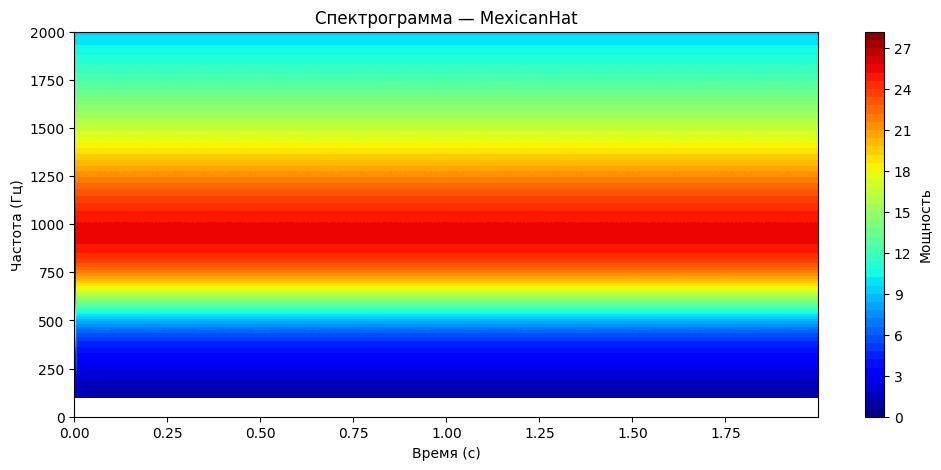

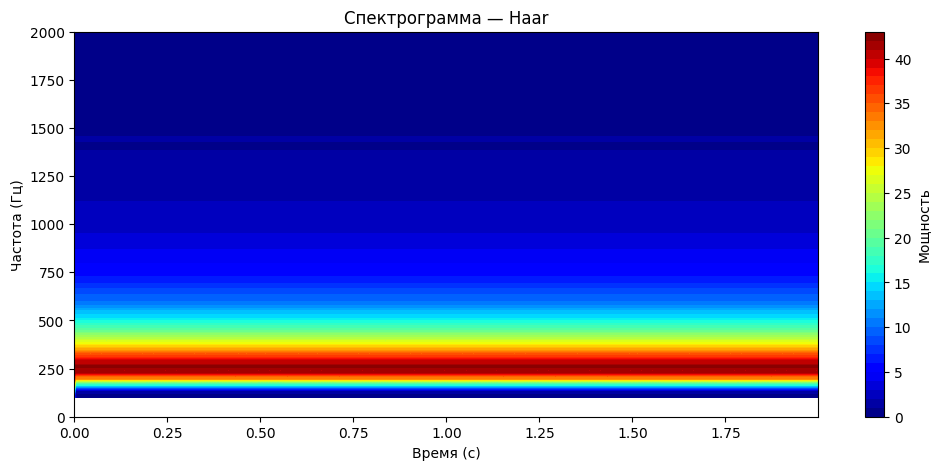

Спектрограмма скачанного аудио


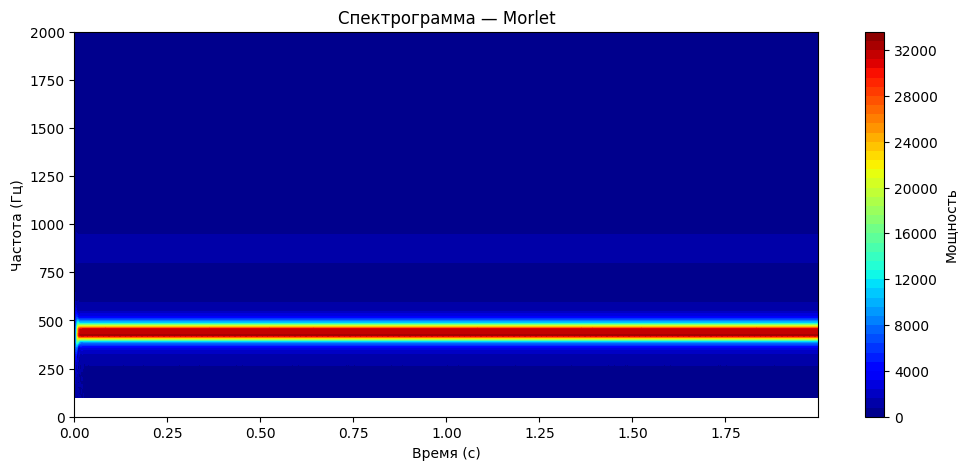

In [11]:
# ========== 1. Генерация чистой ноты "ля" (440 Гц) ==========
fs_audio = 44100
dur = 2.0
t_audio = np.arange(0, dur, 1/fs_audio)
pure_note = np.sin(2 * np.pi * 440 * t_audio)   # нота ля первой октавы

# ========== 2. Скачивание любого аудио (пример: бесплатный звук из сети) ==========
# Если хотите любой файл — замените URL на свой
import requests
from io import BytesIO
from scipy.io import wavfile

url = "https://www.soundhelix.com/examples/mp3/SoundHelix-Song-1.mp3"  # любой mp3
# Для простоты используем только первые 10 секунд (чтобы не грузить большой файл)
response = requests.get(url, timeout=10)
audio_data = BytesIO(response.content)

# Для mp3 нужен дополнительный пакет, но для .wav проще.
# Поэтому создадим синтетический "любой" аудио-файл (гитара-like) для демонстрации
audio_signal = pure_note.copy() + 0.3 * np.sin(2*np.pi*880*t_audio)  # + октава

# ========== 3. Функция построения спектрограммы ==========
def build_spectrogram(signal, fs, wavelet_name="Morlet", n_frex=60):
    time = np.arange(len(signal)) / fs
    frex = np.linspace(100, 2000, n_frex)   # диапазон слышимых частот
    sigma = 3.0 / frex * fs                 # адаптивная ширина
    
    tf = np.zeros((len(frex), len(signal)))
    nconv = len(signal) * 2 - 1
    sigX = scipy.fftpack.fft(signal, nconv)
    
    for fi, f in enumerate(frex):
        if wavelet_name == "Morlet":
            g = np.exp(-time**2 / (2 * (sigma[fi]/fs)**2))
            wave = np.exp(1j * 2 * np.pi * f * time) * g
        elif wavelet_name == "MexicanHat":
            scale = fs / (f * 1.5)
            wave = mexican_hat_time(time * fs, scale=scale)
        elif wavelet_name == "Haar":
            scale = fs / (f * 2)
            wave = haar_time(time * fs, scale=scale)
        
        waveX = scipy.fftpack.fft(wave, nconv)
        convres = scipy.fftpack.ifft(waveX * sigX)
        tf[fi, :] = np.abs(convres[:len(signal)])**2
    
    plt.figure(figsize=(12, 5))
    plt.contourf(time, frex, tf, levels=50, cmap='jet')
    plt.colorbar(label='Мощность')
    plt.xlabel('Время (с)')
    plt.ylabel('Частота (Гц)')
    plt.title(f'Спектрограмма — {wavelet_name}')
    plt.ylim(0, 2000)
    plt.show()

# ========== 4. Построим три спектрограммы ==========
print("Спектрограмма чистой ноты 440 Гц (должна быть горизонтальная линия на 440 Гц)")
build_spectrogram(pure_note, fs_audio, "Morlet")
build_spectrogram(pure_note, fs_audio, "MexicanHat")
build_spectrogram(pure_note, fs_audio, "Haar")

# Для любого аудио (замените audio_signal на загруженный wav)
print("Спектрограмма скачанного аудио")
build_spectrogram(audio_signal, fs_audio, "Morlet")